# Homework: Pre-training a DNA Language Model from Scratch
> **Due Date: March 6th, 2026 @ 1:00pm**
>
> Please turn in this completed notebook via Google classroom. Slack or email Alex or Vishvak if you run into any issues.

**Collaboration policy and more**

You're welcome (and highly encouraged) to work with and discuss this homework assignment with others in the class, and feel free to use any resources (textbooks, online notebooks, etc). The only requirement is that the final notebook that you turn in must be your own written work (no copy and pasting, please).

**Overview**
In this assignment you will build and pre-train a BERT-style DNA encoder for CDS (coding sequences) using **Masked Language Modeling (MLM)**, then evaluate what it has learned by probing its representations on a species classification task.

The core idea: train a model to predict randomly masked nucleotides from their context. If the model succeeds, its internal representations should capture real biological structure — things like sequence composition, k-mer statistics, and the signals that distinguish coding sequences between species — without ever being told about any of those things explicitly.

## What you will implement
- **Part 1**: DNA tokenizer
- **Part 2**: Scaled dot-product attention
- **Part 3**: BERT-style encoder architecture
- **Part 4**: MLM loss function
- **Part 5**: Linear probe & fine-tuning for species classification

## What is provided
- Multi-head attention wrapper
- Masking utilities
- Dataset class and training loop
- Visualization code

## **USE a GPU**
- Connect -> change runtime type -> T4 GPU

## Data Uploading
- Before running the notebook, upload the provided files `pretrain_sequences.csv` and `species_classification.csv`. Drag and drop them in the `sample_data/` folder, accessed by clicking the folder icon on the left sidebar in Colab.

In [ ]:
# !pip install torch pandas numpy matplotlib tqdm seaborn scikit-learn umap-learn

In [10]:
import math, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import umap

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from tqdm import tqdm
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

/Users/zhwu_cecilia/miniconda3/envs/BMIHW3/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


## Load Data

Update the paths below. The MLM pre-training data just needs a `sequence` column of DNA strings. The classification data needs a `sequence` column and a `label` column (e.g. `species`)

These datasets are protein coding sequences (CDS) taken from yeast, arabidopsis and E. Coli. They have been chunked into 128bp lengths. The classification sequences are held out from the pretrain set, though come from the same organisms as those in the pretrained dataset.

In [11]:
pretrain_df = pd.read_csv('/Users/zhwu_cecilia/Documents/BMI212_HW3_BMI212/sample_data/pretrain_sequences.csv')   # columns: sequence
classify_df = pd.read_csv('/Users/zhwu_cecilia/Documents/BMI212_HW3_BMI212/sample_data/species_classification.csv')     # columns: sequence, label

print(f'Pre-train sequences : {len(pretrain_df):,}')
print(f'Classification seqs : {len(classify_df):,}')
print(f'Element types       : {sorted(classify_df["label"].unique())}')

Pre-train sequences : 89,041
Classification seqs : 22,734
Element types       : ['arabidopsis', 'ecoli', 'yeast']


---
# Part 1 — Tokenizer

We tokenize DNA at the **nucleotide level** — one token per character. The vocabulary is tiny: just A, T, C, G plus five special tokens.

| Token | ID | Purpose |
|-------|----|---------|
| `<PAD>` | 0 | Padding to equal-length batches |
| `<CLS>` | 1 | Prepended to every sequence; its final hidden state is the sequence representation |
| `<EOS>` | 2 | Appended to every sequence |
| `<UNK>` | 3 | Any character not in the alphabet |
| `<MASK>` | 4 | Replaces tokens that the model must predict |
| A | 5 | |
| T | 6 | |
| C | 7 | |
| G | 8 | |

### Worked example

Here is a complete tokenizer for a 6-amino-acid alphabet so you can see the pattern before implementing your own:

```python
class ExampleTokenizer:
    SPECIAL = ['<PAD>', '<CLS>', '<EOS>', '<UNK>', '<MASK>']

    def __init__(self, alphabet):
        all_tokens   = self.SPECIAL + alphabet
        self.vocab   = {tok: i for i, tok in enumerate(all_tokens)}
        self.id2char = {i: tok for tok, i in self.vocab.items()}
        self.pad_id  = self.vocab['<PAD>']
        self.cls_id  = self.vocab['<CLS>']
        self.eos_id  = self.vocab['<EOS>']
        self.unk_id  = self.vocab['<UNK>']
        self.mask_id = self.vocab['<MASK>']

    def encode(self, seq):
        ids = [self.vocab.get(c, self.unk_id) for c in seq]
        return [self.cls_id] + ids + [self.eos_id]

    def decode(self, ids):
        special = set(range(len(self.SPECIAL)))
        return ''.join(self.id2char[i] for i in ids if i not in special)

tok = ExampleTokenizer(['A','C','D','E','F','G'])
print(tok.encode('ACEG'))        # [1, 5, 6, 8, 9, 2]
print(tok.decode([1,5,6,8,9,2])) # 'ACEG'
```

In [36]:
class DNATokenizer:
    """
    Nucleotide-level tokenizer with CLS, EOS, PAD, UNK, and MASK tokens.
    """
    SPECIAL  = ['<PAD>', '<CLS>', '<EOS>', '<UNK>', '<MASK>']
    ALPHABET = ['A', 'T', 'C', 'G']

    def __init__(self):
        all_tokens  = self.SPECIAL + self.ALPHABET
        # TODO (1.1): Build self.vocab (str->int) and self.id2char (int->str).
        self.vocab  = {tok: i for i, tok in enumerate(all_tokens)}
        self.id2char = {i: tok for tok, i in self.vocab.items()}
        # Special tokens occupy IDs 0-4 in SPECIAL order; A/T/C/G follow.
        # Set self.pad_id, self.cls_id, self.eos_id, self.unk_id, self.mask_id.
        self.pad_id = self.vocab['<PAD>']
        self.cls_id = self.vocab['<CLS>']
        self.eos_id = self.vocab['<EOS>']
        self.unk_id = self.vocab['<UNK>']
        self.mask_id = self.vocab['<MASK>']
        # nucleotide id
        self.A_id = self.vocab['A']
        self.T_id = self.vocab['T']
        self.C_id = self.vocab['C']
        self.G_id = self.vocab['G']

    @property
    def vocab_size(self):
        return len(self.vocab)

    def encode(self, sequence: str) -> list[int]:
        """
        Convert a DNA string to token IDs.
        Prepend CLS, append EOS. Unknown characters map to UNK.
        """
        # TODO
        ids = [self.vocab.get(c, self.unk_id) for c in sequence]
        return [self.cls_id] + ids + [self.eos_id]

    def decode(self, token_ids: list[int]) -> str:
        """
        Convert token IDs back to a string, stripping all special tokens.
        """
        # TODO
        special = set(range(len(self.SPECIAL)))
        return ''.join(self.id2char[i] for i in token_ids if i not in special)

    def pad_batch(self, sequences: list[list[int]]) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Right-pad a list of encoded sequences to the same length.

        Returns
        -------
        padded  : LongTensor (batch, max_len)
        lengths : LongTensor (batch,)
        """
        lengths = torch.tensor([len(s) for s in sequences], dtype=torch.long)
        max_len = lengths.max().item()
        padded  = torch.full((len(sequences), max_len), self.pad_id, dtype=torch.long)
        for i, seq in enumerate(sequences):
            padded[i, :len(seq)] = torch.tensor(seq, dtype=torch.long)
        return padded, lengths

In [21]:
tok = DNATokenizer()
print(tok.encode('ATCG'))
print(tok.decode([1, 5, 6, 7, 8, 2]))

[1, 5, 6, 7, 8, 2]
ATCG


In [37]:
# ----- Sanity checks —----- #
tokenizer = DNATokenizer()


assert tokenizer.vocab_size == 9,  f'Expected 9, got {tokenizer.vocab_size}'
assert tokenizer.pad_id  == 0
assert tokenizer.cls_id  == 1
assert tokenizer.eos_id  == 2
assert tokenizer.unk_id  == 3
assert tokenizer.mask_id == 4

enc = tokenizer.encode('ATCG')
assert enc[0]  == tokenizer.cls_id
assert enc[-1] == tokenizer.eos_id
assert tokenizer.decode(enc) == 'ATCG', f'Round-trip failed: {tokenizer.decode(enc)}'
assert tokenizer.unk_id in tokenizer.encode('ATNC'), 'N should map to UNK'

padded, lengths = tokenizer.pad_batch([tokenizer.encode('AT'), tokenizer.encode('ATCGATCG')])
assert padded.shape == (2, lengths.max().item())
assert (padded[0, lengths[0]:] == tokenizer.pad_id).all()

print('All Part 1 checks passed!')

All Part 1 checks passed!


---
# Part 2 — Scaled Dot-Product Attention

The fundamental operation of the Transformer:

$$
\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right) V
$$

The $\sqrt{d_k}$ scaling prevents dot products from growing large and pushing the softmax into near-zero-gradient regions.

In [38]:
def scaled_dot_product_attention(
    Q: torch.Tensor,
    K: torch.Tensor,
    V: torch.Tensor,
    mask: torch.Tensor | None = None,
) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Parameters
    ----------
    Q    : (..., T_q, d_k)
    K    : (..., T_k, d_k)
    V    : (..., T_k, d_v)
    mask : bool tensor broadcastable to (..., T_q, T_k)
           True = ignore this position (set score to -1e9 before softmax)

    Returns
    -------
    output       : (..., T_q, d_v)
    attn_weights : (..., T_q, T_k)
    """

    # (2.1) Compute raw attention scores (Provided)
    # scores = Q K^T
    scores = torch.matmul(Q, K.transpose(-2, -1))

    # (2.2) Scale scores by sqrt(d_k) (TODO)
    d_k = Q.shape[-1] #last dim of K or Q
    scores = scores / math.sqrt(d_k) #sqrt d_k scaling

    # (2.3) Apply mask (if provided) (Provided)
    if mask is not None:
        scores = scores.masked_fill(mask, -1e9)

    # (2.4) Apply softmax over key dimension (Provided)
    attn_weights = F.softmax(scores,dim=-1)

    # (2.5) Compute weighted sum of values (TODO, hint: use torch.matmul)
    output = torch.matmul(attn_weights, V)
    
    return output, attn_weights

**Q2.6**: Briefly describe what the scores in the attention mechanism represent
    Score is the dot product between query vector q_i and key vector k_j, representing the similarity measures between queries and keys. Where query and key vectors points in similar directions in feature space, the dot product is large and positive, and vice versa. After softmax, scores become attention weights, determines how much of each value vector contributes to the output.

In [39]:
# ── Multi-head attention — PROVIDED ──────────────────────────────────────────
# You do not need to implement this. It calls your scaled_dot_product_attention.

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model: int, num_heads: int, dropout: float = 0.1):
        super().__init__()
        assert d_model % num_heads == 0
        self.num_heads = num_heads
        self.d_k       = d_model // num_heads
        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor, mask: torch.Tensor | None = None):
        B, T, _ = x.shape
        def split_heads(t):
            return t.view(B, T, self.num_heads, self.d_k).transpose(1, 2)
        Q = split_heads(self.W_q(x))
        K = split_heads(self.W_k(x))
        V = split_heads(self.W_v(x))
        if mask is not None:
            mask = mask.unsqueeze(1).unsqueeze(2)   # (B,1,1,T)
        out, attn = scaled_dot_product_attention(Q, K, V, mask)
        out = self.dropout(out)
        out = out.transpose(1, 2).contiguous().view(B, T, -1)
        return self.W_o(out), attn

**Q2.7**: What are multi-head attention's gains over regular attention?
    Many attention heads attended to multiple parts of the context. Each QKV attention heads computes in parallel, therefore the model learns how to distribute the attention heads to answer the question in order to solve for the objective tasks. 

In [40]:
# ----- Sanity checks — do not modify -----
torch.manual_seed(0)
B, T, d = 2, 10, 64
Q_ = torch.randn(B, T, d)
K_ = torch.randn(B, T, d)
V_ = torch.randn(B, T, d)

out, w = scaled_dot_product_attention(Q_, K_, V_)
assert out.shape == (B, T, d)
assert w.shape   == (B, T, T)
assert torch.allclose(w.sum(-1), torch.ones(B, T)), 'Weights must sum to 1'

mask = torch.zeros(B, T, dtype=torch.bool)
mask[:, -1] = True
_, w_m = scaled_dot_product_attention(Q_, K_, V_, mask=mask.unsqueeze(1))
assert (w_m[:, :, -1] < 1e-6).all(), 'Masked positions should get ~0 weight'

mha = MultiHeadAttention(d_model=d, num_heads=4)
x_  = torch.randn(B, T, d)
o, a = mha(x_)
assert o.shape == (B, T, d)
assert a.shape == (B, 4, T, T)

print('All Part 2 checks passed!')

All Part 2 checks passed!


## Part 3 — BERT-style Encoder

### Why we build in separate pieces

A transformer encoder is built from a small number of composable building
blocks that each do one thing well. Rather than writing one large monolithic
class, we build them bottom-up:

- `MultiHeadAttention` (already Provided) — knows how to attend
- `EncoderLayer` — knows how to apply one round of attention + FFN with
  residual connections
- `DNAEncoder` — knows how to embed tokens, stack layers, and produce a
  sequence representation

This separation matters for a few reasons. First, it mirrors how the
original Transformer paper thinks about the architecture — layers are
explicitly described as composable units. Second, it makes debugging much
easier: if your attention weights look wrong you know exactly where to look,
rather than hunting through a 200-line class. Third, it reflects real
software practice — PyTorch's own `nn.TransformerEncoderLayer` follows the
same pattern, so understanding this structure lets you read and modify
real library code.



The dependency graph is simple:
```
scaled_dot_product_attention   ← you implement this (Part 2)
        ↓
MultiHeadAttention             ← Provided, calls your function
        ↓
EncoderLayer                   ← you implement this (Part 3.1)
        ↓
DNAEncoder                     ← Provided (stacks of EncoderLayers)
```

Each level only needs to know about the level directly below it.
`DNAEncoder` doesn't know or care how attention is computed —
it just calls `EncoderLayer.forward()` and trusts it to work.

---

### `EncoderLayer`

One `EncoderLayer` is a single pass through two sub-layers, each wrapped
in a residual connection and a layer normalization:
```
Input x
  │
  ├─── MultiHeadAttention(x, x, x) ──► dropout ──► + ──► LayerNorm ──► x'
  │                                                 ↑
  └─────────────────────────────────────────────────┘ (residual)

  x'
  │
  ├─── FFN(x') ──► dropout ──► + ──► LayerNorm ──► output
  │                             ↑
  └─────────────────────────────┘ (residual)
```


The **feed-forward network (FFN)** is just a two-layer MLP applied
identically to every position. Its role is to give each position a chance
to transform its own representation nonlinearly after attention has mixed
information across positions. Attention is the *routing* mechanism; the FFN
is the *processing* mechanism.

---

### `DNAEncoder`

`DNAEncoder` is the full model. It takes a batch of token ID sequences and
produces a **hidden state for every position**, plus a single
**sequence-level representation** from the `<CLS>` token.
```
Token IDs  (batch, seq_len)
      │
  nn.Embedding  ←  converts each integer ID to a d_model-dimensional vector
      │
  × √d_model   ←  scale up so embedding magnitudes match positional encodings
      │
  PositionalEncoding  ←  add sinusoidal position signal so the model knows
      │                   token order (attention itself is permutation-invariant)
      │
  EncoderLayer × N    ←  stack of N identical layers, each refining the
      │                   representation with attention + FFN
      │
  LayerNorm           ←  final normalization of the output representations
      │
  ┌───┴──────────────────────┐
  │                          │
hidden states            CLS token
(batch, seq_len, d_model)  (batch, d_model)
                              ↑
                    position 0 in every sequence
                    is always the <CLS> token.
                    After N layers of full attention
                    it has seen every other position,
                    so it acts as a compressed summary
                    of the whole sequence. This is what
                    we feed to the classifier in Part 5.
```

**Attention is permutation-invariant**. If you shuffled all
the tokens in a sequence, the attention scores would change but the
*mechanism* has no inherent sense of order. The positional encoding is what
injects order information — without it, the model would treat
`ATCGATCG` and `GCTAGCTA` as the same bag of tokens.

The `<CLS>` token is a design choice inherited from BERT. Because every
token attends to every other token (bidirectional attention, no causal
mask), by the final layer the `<CLS>` hidden state is a function of the
entire input sequence. It is a convenient single vector to use for
sequence-level tasks like classification — instead of deciding how to
pool across all positions, we just read off position 0.

In [26]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 2048, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.dropout(x + self.pe[:, :x.size(1)])

Here we define the encoder layer, the building block of the final BERT encoding model

In [41]:
class EncoderLayer(nn.Module):
    """
    Single Transformer encoder layer (post-norm):
        x = LayerNorm(x + SelfAttention(x))
        x = LayerNorm(x + FFN(x))
    """
    def __init__(self, d_model: int, num_heads: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        # (3.1) Define the ffn, nn.Sequential of Linear(d_model,d_ff) -> ReLU -> Linear(d_ff,d_model)
        self.ffn   = nn.Sequential(
        # TODO
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Linear(d_ff, d_model)
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        self.attn = MultiHeadAttention(d_model, num_heads, dropout)

    def forward(self, x: torch.Tensor, pad_mask: torch.Tensor | None = None):
        """
        x        : (batch, seq_len, d_model)
        pad_mask : (batch, seq_len) bool, True where PAD
        Returns  : (batch, seq_len, d_model)
        """
        attn_out, _ = self.attn(x, mask=pad_mask)
        x = self.norm1(x + self.dropout(attn_out))
        x = self.norm2(x + self.dropout(self.ffn(x)))
        return x



**Q3.2:** In the encoder layer, each sublayer follows the pattern:

x = LayerNorm(x + Sublayer(x))

Explain the purpose of:

1. The residual connection

2. LayerNorm

3. Dropout

What problem would arise if each were removed?

*Your answer here.*

In [42]:
# ── DNAEncoder — PROVIDED ────────────────────────────────────────────────

class DNAEncoder(nn.Module):
    """
    BERT-style encoder. Hidden state at position 0 (CLS) is the sequence representation.
    """
    def __init__(
        self,
        vocab_size: int,
        d_model:    int   = 128,
        num_heads:  int   = 4,
        num_layers: int   = 4,
        d_ff:       int   = 256,
        dropout:    float = 0.1,
        pad_id:     int   = 0,
    ):
        super().__init__()
        self.pad_id = pad_id
        self.scale  = math.sqrt(d_model)

        # nn.Embedding embeds the nucleotide tokens into vectors of length d_model
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
        self.pos_enc   = PositionalEncoding(d_model, dropout=dropout)
        self.layers    = nn.ModuleList([
            EncoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        self.norm = nn.LayerNorm(d_model)

    def forward(self, src: torch.Tensor):
        """
        src : (batch, seq_len)  token IDs

        Returns
        -------
        hidden : (batch, seq_len, d_model)  all position hidden states
        cls    : (batch, d_model)           CLS token representation (position 0)
        """
        # Full forward pass
        # 1. Padding mask: True where PAD
        pad_mask = (src == self.pad_id)   # (B, T)

        # 2. Embed + positional encoding
        x = self.embedding(src)
        x = self.pos_enc(x)

        # 3. Encoder layers
        for layer in self.layers:
            x = layer(x, pad_mask=pad_mask)

        # 4. Final norm
        x = self.norm(x)

        # 5. Return all hidden states and CLS (position 0)
        return x, x[:, 0, :]

In [43]:
# ----- Sanity checks — do not modify -----
model = DNAEncoder(
    vocab_size=tokenizer.vocab_size, d_model=128,
    num_heads=4, num_layers=4, d_ff=256, pad_id=tokenizer.pad_id
).to(device)

print(model)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parameters: {n_params:,}')



DNAEncoder(
  (embedding): Embedding(9, 128, padding_idx=0)
  (pos_enc): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (layers): ModuleList(
    (0-3): 4 x EncoderLayer(
      (ffn): Sequential(
        (0): Linear(in_features=128, out_features=256, bias=True)
        (1): ReLU()
        (2): Linear(in_features=256, out_features=128, bias=True)
      )
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (attn): MultiHeadAttention(
        (W_q): Linear(in_features=128, out_features=128, bias=False)
        (W_k): Linear(in_features=128, out_features=128, bias=False)
        (W_v): Linear(in_features=128, out_features=128, bias=False)
        (W_o): Linear(in_features=128, out_features=128, bias=False)
        (dropout): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=

---
# Part 4 — MLM Loss

In **Masked Language Modeling** (Devlin et al., BERT 2019) we:

1. Randomly select ~15% of non-special tokens
2. Replace 80% of them with `<MASK>`, 10% with a random token, 10% leave unchanged
3. Ask the model to predict the **original** token at each selected position
4. Compute cross-entropy loss **only at those positions** — not the whole sequence

```
Original:  [CLS]  A   T   C   G   A   T   [EOS]
Masked:    [CLS]  A  [M]  C  [M]  A   T   [EOS]
Loss at:              ↑        ↑
```

In practice, we can index **non-masked** tokens with a special value (-100), and the cross entropy loss function can accept this special value in order to ignore indexes that are not masked.



In [44]:
# ── Masking utility — PROVIDED ────────────────────────────────────────────────

def apply_mlm_mask(
    input_ids:      torch.Tensor,
    mask_token_id:  int,
    vocab_size:     int,
    special_ids:    set,
    num_special:    int = 5,
    mask_prob:      float = 0.15,
):

    device = input_ids.device

    labels     = torch.full_like(input_ids, -100)
    masked_ids = input_ids.clone()

    special_mask = torch.zeros_like(input_ids, dtype=torch.bool)
    for sid in special_ids:
        special_mask |= (input_ids == sid)

    # --- select tokens to mask ---
    prob_matrix = torch.full(input_ids.shape, mask_prob, device=device)
    prob_matrix[special_mask] = 0.0
    selected = torch.bernoulli(prob_matrix).bool()

    labels[selected] = input_ids[selected]

    # --- 80% replace with mask token ---
    replace_prob = torch.full(input_ids.shape, 0.8, device=device)
    replace = torch.bernoulli(replace_prob).bool() & selected
    masked_ids[replace] = mask_token_id

    # --- 10% replace with random token ---
    random_prob = torch.full(input_ids.shape, 0.5, device=device)
    random_replace = torch.bernoulli(random_prob).bool() & selected & ~replace

    rand_tokens = torch.randint(
        low=num_special,
        high=vocab_size,
        size=input_ids.shape,
        device=device
    )

    masked_ids[random_replace] = rand_tokens[random_replace]

    return masked_ids, labels, selected

For our pretraining task, we define an MLM head. As you will see in the next section, we throw away this head and replace it with a classification head. As we move from pretraining -> fine tuning, we use the same encoder and swappable head. This is exactly how BERT, GPT, and every modern pretrained model works — the "backbone" is separate from the "task" head.

In [45]:

# ── MLM prediction head — PROVIDED ───────────────────────────────────────────

class MLMHead(nn.Module):
    def __init__(self, d_model: int, vocab_size: int):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.LayerNorm(d_model),
            nn.Linear(d_model, vocab_size),
        )
    def forward(self, x): return self.proj(x)

In [46]:
# ── MLM loss — PROVIDED ───────────────────────────────────────────
def mlm_loss(logits: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
    """
    Cross-entropy loss over masked positions only.

    Parameters
    ----------
    logits : (batch, seq_len, vocab_size)
    labels : (batch, seq_len)  — original token IDs at masked positions, -100 elsewhere

    Returns
    -------
    scalar loss

    """
    return F.cross_entropy(
        logits.view(-1, logits.size(-1)),
        labels.view(-1),
        ignore_index=-100,
    )

**Q4.1**: Why do we set non-masked positions to -100 in the labels tensor rather than just computing loss over the whole sequence?

*Your answer here.*

**Q4.2** What is the expected value of the MLM loss at random initialization, and why? Your answer should reference the vocabulary size.

*Your answer here.*


---
# Pre-training

The following cells run MLM pre-training. **Provided — do not modify.** Read through and make sure you understand what each step does.

In [33]:
device='cuda' if torch.cuda.is_available() else 'cpu'

In [47]:
# ── Dataset & DataLoader — PROVIDED ──────────────────────────────────────────

class DNADataset(Dataset):
    def __init__(self, sequences, tok):
        self.encoded = [tok.encode(s) for s in sequences]
    def __len__(self):        return len(self.encoded)
    def __getitem__(self, i): return self.encoded[i]

def collate(batch):
    padded, lengths = tokenizer.pad_batch(batch)
    return padded.to(device), lengths

BATCH_SIZE = 64
seqs  = pretrain_df['sequence'].tolist()
split = int(0.9 * len(seqs))
train_loader = DataLoader(DNADataset(seqs[:split], tokenizer),
                          batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate)
val_loader   = DataLoader(DNADataset(seqs[split:], tokenizer),
                          batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate)
print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

Train batches: 1253 | Val batches: 140


**Q4.3** What does the collate function do here?

*Your answer here.

In [50]:
# ── Training loop — PROVIDED ──────────────────────────────────────────────────
SPECIAL_IDS = {tokenizer.pad_id, tokenizer.cls_id, tokenizer.eos_id, tokenizer.unk_id}

DNABert  = DNAEncoder(
    vocab_size=tokenizer.vocab_size, d_model=128,
    num_heads=4, num_layers=4, d_ff=256, pad_id=tokenizer.pad_id
).to(device)
mlm_head = MLMHead(128, tokenizer.vocab_size).to(device)

optimizer = torch.optim.AdamW(
    list(DNABert.parameters()) + list(mlm_head.parameters()),
    lr=1e-3, weight_decay=0.01
)

NUM_EPOCHS   = 10
train_losses, val_losses = [], []

'''
for epoch in range(1, NUM_EPOCHS + 1):
    DNABert.train();  mlm_head.train()
    ep_loss = 0

    for ids, _ in tqdm(train_loader, desc=f'Epoch {epoch}/{NUM_EPOCHS} [Train]'):
        masked, labels, _ = apply_mlm_mask(
            ids, tokenizer.mask_id, tokenizer.vocab_size, SPECIAL_IDS)
        hidden, _ = DNABert(masked)
        loss = mlm_loss(mlm_head(hidden), labels)
        optimizer.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(DNABert.parameters(), 1.0)
        optimizer.step()
        ep_loss += loss.item()
    train_losses.append(ep_loss / len(train_loader))

    DNABert.eval();   mlm_head.eval()
    v_loss = 0
    with torch.no_grad():
        for ids, _ in tqdm(val_loader, desc=f'Epoch {epoch}/{NUM_EPOCHS} [Val]'):
            masked, labels, _ = apply_mlm_mask(
                ids, tokenizer.mask_id, tokenizer.vocab_size, SPECIAL_IDS)
            hidden, _ = DNABert(masked)
            v_loss += mlm_loss(mlm_head(hidden), labels).item()
    val_losses.append(v_loss / len(val_loader))

    if epoch % 4 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d}  train: {train_losses[-1]:.4f}  val: {val_losses[-1]:.4f}')

torch.save({'DNABert': encoder.state_dict()}, 'pretrained_encoder.pt')
print('Saved pretrained_encoder.pt')
'''

"\nfor epoch in range(1, NUM_EPOCHS + 1):\n    DNABert.train();  mlm_head.train()\n    ep_loss = 0\n\n    for ids, _ in tqdm(train_loader, desc=f'Epoch {epoch}/{NUM_EPOCHS} [Train]'):\n        masked, labels, _ = apply_mlm_mask(\n            ids, tokenizer.mask_id, tokenizer.vocab_size, SPECIAL_IDS)\n        hidden, _ = DNABert(masked)\n        loss = mlm_loss(mlm_head(hidden), labels)\n        optimizer.zero_grad(); loss.backward()\n        torch.nn.utils.clip_grad_norm_(DNABert.parameters(), 1.0)\n        optimizer.step()\n        ep_loss += loss.item()\n    train_losses.append(ep_loss / len(train_loader))\n\n    DNABert.eval();   mlm_head.eval()\n    v_loss = 0\n    with torch.no_grad():\n        for ids, _ in tqdm(val_loader, desc=f'Epoch {epoch}/{NUM_EPOCHS} [Val]'):\n            masked, labels, _ = apply_mlm_mask(\n                ids, tokenizer.mask_id, tokenizer.vocab_size, SPECIAL_IDS)\n            hidden, _ = DNABert(masked)\n            v_loss += mlm_loss(mlm_head(hidden), l

**Q4.4** What is the purpose of constructing a validation set?

*Your answer here.

**Q4.5** Briefly explain the steps in the training loop

*Your answer here.

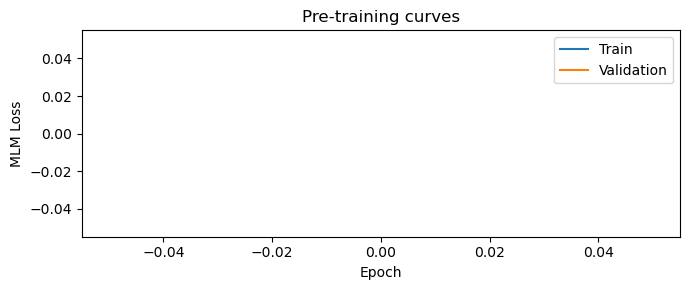

In [51]:
plt.figure(figsize=(7, 3))
plt.plot(train_losses, label='Train')
plt.plot(val_losses,   label='Validation')
plt.xlabel('Epoch'); plt.ylabel('MLM Loss')
plt.title('Pre-training curves'); plt.legend(); plt.tight_layout(); plt.show()

In practice, state-of-the-art DNA Transformers (like DNABERT, Nucleotide Transformer, Evo2) are trained on trillions of base pairs using models with billions of parameters. For this assignment, we are working with a much smaller dataset and a lightweight 4-layer architecture. While a real-world model might train for weeks on industrial hardware, let’s see what biological signals we can capture in just 20 epochs on a single T4 GPU.

We do not expect a sharp decrease in loss, but lets see how 20 epochs on our small dataset helps us with our classification task:

---
# Part 5 — Probing and Fine-tuning

Now we test whether the encoder has learned representations that capture **species identity** — even though it was never trained on this task.

We compare three setups:

| Setup | Encoder weights | Classifier |
|-------|----------------|------------|
| **Baseline** | Random init, frozen | Logistic regression |
| **Linear probe** | Pretrained, frozen | Logistic regression |
| **Fine-tuning** | Pretrained, trainable | Linear head |

The baseline shows what a random encoder gives you — essentially composition statistics and nothing more. If the linear probe beats it, the pretrained representations contain structure the model learned from MLM.

Note on experimental design: The sequences used for the linear probe and fine-tuning are held-out chunks that were not seen during pretraining, but they come from the same three species the encoder was pretrained on. This means the encoder has already been exposed to the statistical signatures of each species — codon usage, GC content, k-mer frequencies — during MLM. Keep this in mind when interpreting your results in 5.2 and 5.3

In [52]:
# ── Data preparation — PROVIDED ───────────────────────────────────────────────

label2id = {lbl: i for i, lbl in enumerate(sorted(classify_df['label'].unique()))}
id2label = {v: k for k, v in label2id.items()}
num_classes = len(label2id)
print('Classes:', label2id)

classify_df = classify_df.sample(frac=1, random_state=SEED).reset_index(drop=True)
n  = len(classify_df)
tr = classify_df.iloc[:int(0.7*n)]
va = classify_df.iloc[int(0.7*n):int(0.85*n)]
te = classify_df.iloc[int(0.85*n):]

class LabeledDNADataset(Dataset):
    def __init__(self, df):
        self.seqs   = [tokenizer.encode(s) for s in df['sequence']]
        self.labels = [label2id[l] for l in df['label']]
    def __len__(self):        return len(self.seqs)
    def __getitem__(self, i): return self.seqs[i], self.labels[i]

def labeled_collate(batch):
    seqs, labels = zip(*batch)
    padded, _ = tokenizer.pad_batch(list(seqs))
    return padded.to(device), torch.tensor(labels, dtype=torch.long).to(device)

tr_loader = DataLoader(LabeledDNADataset(tr), batch_size=32, shuffle=True,  collate_fn=labeled_collate)
va_loader = DataLoader(LabeledDNADataset(va), batch_size=32, shuffle=False, collate_fn=labeled_collate)
te_loader = DataLoader(LabeledDNADataset(te), batch_size=32, shuffle=False, collate_fn=labeled_collate)

@torch.no_grad()
def extract_cls(encoder, loader):
    """Extract CLS representations and labels as numpy arrays."""
    encoder.eval()
    reps, lbls = [], []
    for ids, labels in loader:
        _, cls = encoder(ids)
        reps.append(cls.cpu().numpy())
        lbls.append(labels.cpu().numpy())
    return np.concatenate(reps), np.concatenate(lbls)

Classes: {'arabidopsis': 0, 'ecoli': 1, 'yeast': 2}


## 5.1 — Embedding Space Visualization

/Users/zhwu_cecilia/miniconda3/envs/BMIHW3/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


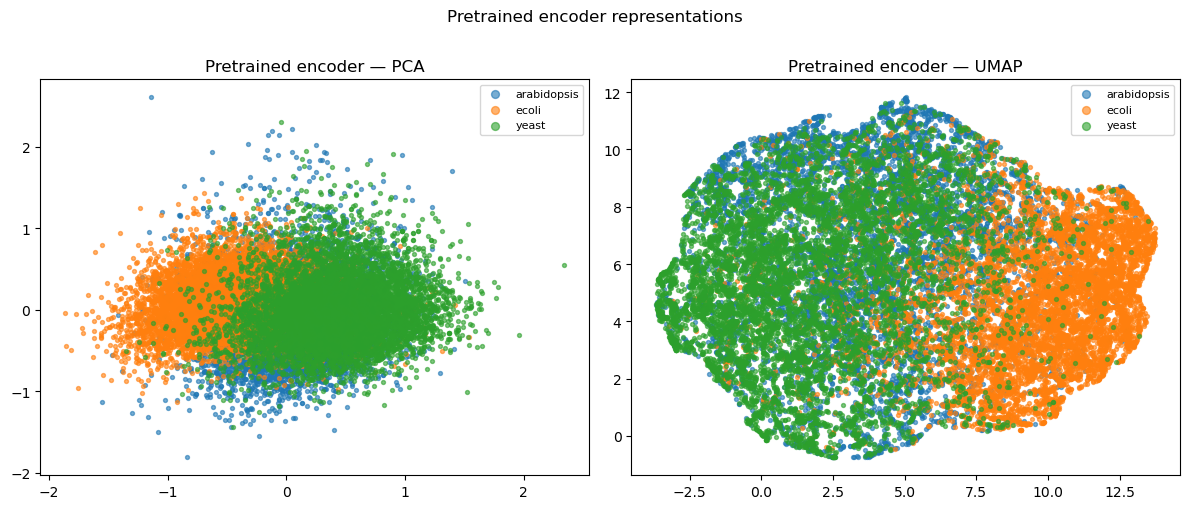

In [55]:
# ── Pretrained encoder visualization — PROVIDED ───────────────────────────────
# Run this cell as-is once your DNABert is trained.

all_loader = DataLoader(LabeledDNADataset(classify_df), batch_size=64, collate_fn=labeled_collate)
reps_pt, lbls_all = extract_cls(DNABert, all_loader)

pca_pt   = PCA(n_components=2).fit_transform(reps_pt)
umap_pt  = umap.UMAP(n_components=2, random_state=SEED).fit_transform(reps_pt)
palette  = sns.color_palette('tab10', num_classes)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, coords, title in zip(axes, [pca_pt, umap_pt], ['PCA', 'UMAP']):
    for i, lbl in id2label.items():
        m = lbls_all == i
        ax.scatter(coords[m, 0], coords[m, 1], s=8, alpha=0.6, color=palette[i], label=lbl)
    ax.set_title(f'Pretrained encoder — {title}'); ax.legend(markerscale=2, fontsize=8)
plt.suptitle('Pretrained encoder representations', y=1.01)
plt.tight_layout(); plt.show()

/Users/zhwu_cecilia/miniconda3/envs/BMIHW3/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


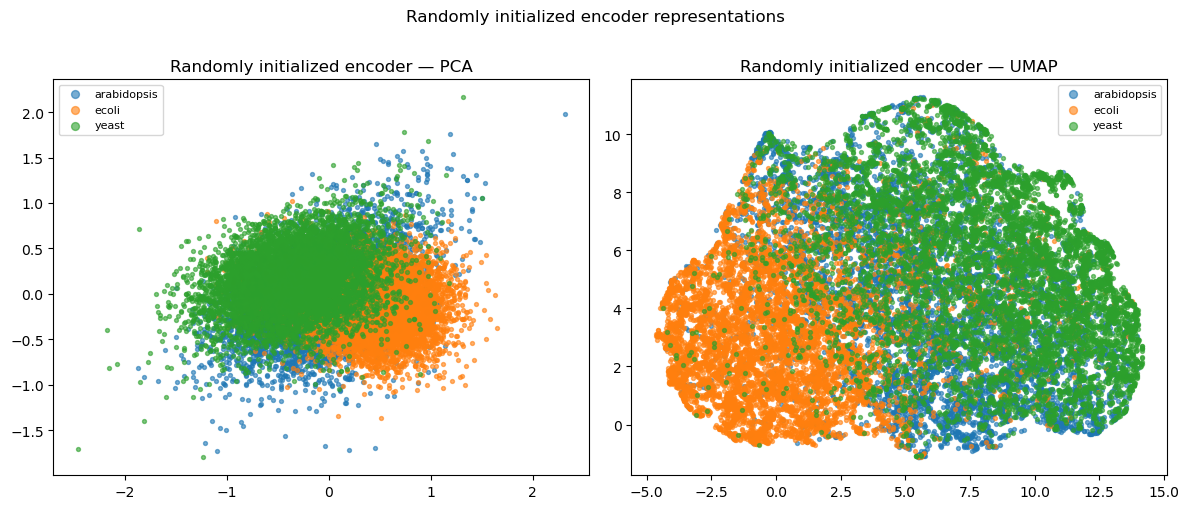

In [54]:
# TODO (5.1): Produce the same PCA + UMAP plots for a randomly initialized encoder.
# Use the same classify_df data and the same palette so the plots are comparable.
# This is your baseline — it shows the geometry without any learned representation.

random_encoder = DNAEncoder(
    vocab_size=tokenizer.vocab_size, d_model=128, num_heads=4,
    num_layers=4, d_ff=256, pad_id=tokenizer.pad_id
).to(device)


# Your visualization code here
all_loader = DataLoader(LabeledDNADataset(classify_df), batch_size=64, collate_fn=labeled_collate)
reps_pt, lbls_all = extract_cls(random_encoder, all_loader)

pca_pt   = PCA(n_components=2).fit_transform(reps_pt)
umap_pt  = umap.UMAP(n_components=2, random_state=SEED).fit_transform(reps_pt)
palette  = sns.color_palette('tab10', num_classes)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, coords, title in zip(axes, [pca_pt, umap_pt], ['PCA', 'UMAP']):
    for i, lbl in id2label.items():
        m = lbls_all == i
        ax.scatter(coords[m, 0], coords[m, 1], s=8, alpha=0.6, color=palette[i], label=lbl)
    ax.set_title(f'Randomly initialized encoder — {title}'); ax.legend(markerscale=2, fontsize=8)
plt.suptitle('Randomly initialized encoder representations', y=1.01)
plt.tight_layout(); plt.show()

**Question 5.1**: Compare the pretrained and random encoder visualizations. Do species cluster in a biologically meanigful way?

*Your answer here.*

## 5.2 — Linear Probe

Freeze the encoder and fit a logistic regression on the CLS representations. If the classes are linearly separable in the frozen space, the model has already encoded the relevant structure.

In [64]:
# TODO (5.2): Implement and evaluate the linear probe.
from sklearn.metrics import accuracy_score, classification_report
# Steps:
def run_linear_probe(encoder, name='encoder'):
    #   1. Freeze the pretrained DNABert (set requires_grad=False for all parameters)
    for p in encoder.parameters():
        p.requires_grad=False
    #   2. Use extract_cls() to get train/test CLS representations (Provided)
    tr_reps_pt,  tr_lbls = extract_cls(encoder, tr_loader)
    te_reps_pt,  te_lbls = extract_cls(encoder, te_loader)
    #   3. Fit a LogisticRegression (sklearn) on the train representations
    Linear = LogisticRegression(
        solver='lbfgs'
    )
    Linear.fit(tr_reps_pt, tr_lbls)
    #   4. Print accuracy and classification_report (sklearn) on the test set
    y_pred = Linear.predict(te_reps_pt)
    acc = accuracy_score(te_lbls, y_pred)
    report = classification_report(te_lbls, y_pred, digits=4)

    print(f'=== Linear probe on {name} ===')
    print(f'Accuracy: {acc:.4f}')
    print('Classification report:')
    print(report)
    print('---------------------------')

    return {'Linear': Linear, 'accuracy': acc, 'report': report}
    #   5. Repeat steps 2-4 for the random_encoder as a baseline
results_pretrained = run_linear_probe(DNABert, name='pretrained_DNABert')
results_random = run_linear_probe(random_encoder, name='random_encoder_baseline')

/Users/zhwu_cecilia/miniconda3/envs/BMIHW3/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


=== Linear probe on pretrained_DNABert ===
Accuracy: 0.7048
Classification report:
              precision    recall  f1-score   support

           0     0.6165    0.5800    0.5977      1150
           1     0.7950    0.8310    0.8126      1148
           2     0.6935    0.7035    0.6985      1113

    accuracy                         0.7048      3411
   macro avg     0.7017    0.7048    0.7029      3411
weighted avg     0.7017    0.7048    0.7029      3411

---------------------------
=== Linear probe on random_encoder_baseline ===
Accuracy: 0.7039
Classification report:
              precision    recall  f1-score   support

           0     0.6196    0.5722    0.5949      1150
           1     0.7993    0.8328    0.8157      1148
           2     0.6826    0.7071    0.6946      1113

    accuracy                         0.7039      3411
   macro avg     0.7005    0.7040    0.7018      3411
weighted avg     0.7006    0.7039    0.7018      3411

---------------------------


/Users/zhwu_cecilia/miniconda3/envs/BMIHW3/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**Q 5.2** : Is the linear probe substantially above the random baseline? Which element types are easiest/hardest to separate, and why might that be biologically?

*Your answer here.*

## 5.3 — Fine-tuning (Extra Credit)

Now want to replace the MLM head with a classification head, and fine tune both the classification head and encoder with Cross Entropy Loss. Fine-tuning is sensitive to hyperparameters and results can vary. A reasonable implementation that trains without errors is sufficient — you do not need to beat the linear probe. In this dataset, the pretrained encoder has already seen sequences from all three species during MLM, so it has implicitly learned species-distinguishing features without any labels. This means the linear probe is already operating on highly discriminative representations, leaving little room for fine-tuning to improve. The goal here is to implement the pipeline correctly and reflect on what the results tell you about the quality of the pretrained representations.

In [ ]:
# TODO (5.3): Implement head only fine-tuning.
#
# Steps:
#   1. Load a fresh encoder and restore pretrained weights from 'pretrained_encoder.pt' and freeze the encoder
ft_encoder = DNAEncoder(
    vocab_size=tokenizer.vocab_size, d_model=128,
    num_heads=4, num_layers=4, d_ff=256, pad_id=tokenizer.pad_id
).to(device)
checkpoint = torch.load('pretrained_encoder.pt', map_location=device)
ft_encoder.load_state_dict(checkpoint['DNABert'])

#
#   2. Add a classification head (recommendation: linear(128,128) -> ReLU -> linear(128,n_classes) but feel free to play around with architecture here)


#   3. Train for 20 epochs with cross-entropy loss : F.cross_entropy_loss(logits,labels)
#
#      The classifier takes the CLS output:
#          hidden, cls = DNABert(seqs)
#          logits = classifier(cls)

#      For the optimizer, you should use different learning rates for the encoder and for the classification head, something like
#       optimizer = torch.optim.AdamW([
#           {'params': ft_encoder.parameters(), 'lr': 1e-6},
#           {'params': classifier.parameters(), 'lr': 1e-3},
#       ], weight_decay=0.01)


# sample train loop
FT_EPOCHS = 20
ft_train_losses = []

for epoch in range(1, FT_EPOCHS + 1):
    classifier.train()
    ep_loss = 0

    for ids, labels in tqdm(tr_loader, desc=f"{epoch}"):
        optimizer.zero_grad()

        #with torch.no_grad():   # no gradients through encoder
        _, cls = ft_encoder(ids)

        logits = classifier(cls)
        loss = F.cross_entropy(logits, labels)

        loss.backward()
        optimizer.step()

        ep_loss += loss.item()

    ft_train_losses.append(ep_loss / len(tr_loader))



#   4. Print test accuracy and classification_report
#   5. Plot train curves

raise NotImplementedError

**Question 5.3** (Extra Credit):

a) How does your fine-tuning accuracy compare to the linear probe? Given that the encoder was pretrained on sequences from all three species, why might the linear probe be a surprisingly strong baseline here? What would you change about the experimental design to create a setting where fine-tuning more clearly outperforms the linear probe?


*Your answer here.*


b) We initialize fine-tuning from pretrained weights rather than random weights. What is the practical benefit? What would you expect if you fine-tuned from random initialization instead?

*Your answer here.*



**Question 5.4**:

Explain the difference between masked language modeling and causal language modeling. What type of data and application is each objective better suited for?

*Your answer here*